# Extract the snow report from online

### January 2026
### Extracts data from OpenSnow snow reporting site thorugh the paywall and displays it visually
### Make sure the packages below are installed in your env before importing

In [56]:
import sys
print(sys.version)
import pandas as pd
import requests
from bs4 import BeautifulSoup
import requests
from datetime import date
import os
print("All imports OK")

3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
All imports OK


In [58]:
#first time this cell runs it should install the new packages
#install dependencies to be able to extract the data from the OpenSnow site
!pip install selenium webdriver-manager
#for compatibility
!pip install --upgrade typing_extensions

In [47]:
#showing where to save the data
csv_path = "ikon_daily_snow_totals_full.csv"

JSON_BASE = "https://opensnow.com/mtn/compare/season-passes/ikonbase/forecasts/snow-summary"
API_KEY = "60600760edf827a75df71f712b71e3f3"

records = []
limit, skip = 20, 0

def extract_summary(summary, label):
    for s in summary:
        if s.get("display_at_local_label") == label:
            return s.get("precip_snow")
    return None

while True:
    url = (
        f"{JSON_BASE}?v=1&api_key={API_KEY}"
        f"&days=15&dir=asc&limit={limit}&skip={skip}"
        f"&sort=alpha&units=imperial"
    )

    data = requests.get(url).json()
    resorts = data.get("locations", [])
    if not resorts:
        break
    
    for r in resorts:
        history_daily = r.get("history_snow_daily", [])
        history_summary = r.get("history_snow_summary", [])
        forecast_summary = r.get("forecast_snow_summary", [])
    
        # last 24hr snowfall
        last_24 = history_daily[-1]["precip_snow"] if history_daily else None
    
        # coordinates
        coords = r.get("coordinates", {}).get("point", [None, None])
        longitude = coords[0]
        latitude = coords[1]
    
        records.append({
            "date": date.today().isoformat(),
            "resort_name": r.get("name"),
            "location": f"{r.get('state_name','')}, {r.get('country_name','')}".strip(", "),
            "last_24hr_snow": last_24,
            "prev_1_5_days": extract_summary(history_summary, "Prev 1-5 Days"),
            "prev_6_10_days": extract_summary(history_summary, "Prev 6-10 Days"),
            "prev_11_15_days": extract_summary(history_summary, "Prev 11-15 Days"),
            "next_1_5_days": extract_summary(forecast_summary, "Next 1-5 Days"),
            "next_6_10_days": extract_summary(forecast_summary, "Next 6-10 Days"),
            "next_11_15_days": extract_summary(forecast_summary, "Next 11-15 Days"),
            "latitude": latitude,
            "longitude": longitude
        })


    skip += limit

df_new = pd.DataFrame(records)


In [48]:
#check the data now
display(df_new.shape)
display(df_new.head(20))

#save the data to a csv
df_new.to_csv(csv_path, index=False)
print(f"Saved {len(df_new)} rows to {csv_path}")

(108, 12)

,date,resort_name,location,last_24hr_snow,prev_1_5_days,prev_6_10_days,prev_11_15_days,next_1_5_days,next_6_10_days,next_11_15_days,latitude,longitude
0,2026-02-19,3 Zinnen (3 Peaks) Dolomites,"Bolzano, Italy",0.0,3,0,9,10,5,5,46.7127,12.3641
1,2026-02-19,Alpe di Siusi,"Bolzano, Italy",0.0,3,0,5,8,2,5,46.5312,11.6258
2,2026-02-19,Alpental at Snoqualmie,"Washington, United States",3.0,8,3,0,8,32,18,47.4361,-121.4354
3,2026-02-19,Alyeska,"Alaska, United States",NaN,6,6,10,0,4,6,60.9604,-149.0908
4,2026-02-19,Appi Kogen,"Iwate, Japan",6.0,6,8,10,1,12,7,39.9882,140.9620
5,2026-02-19,Arabba,"Belluno, Italy",0.0,4,0,12,11,4,6,46.4842,11.8729
6,2026-02-19,Arapahoe Basin,"Colorado, United States",1.0,7,5,2,3,7,6,39.6324,-105.8710
7,2026-02-19,Banff Sunshine,"Alberta, Canada",0.0,10,2,3,2,7,6,51.0924,-115.7667
8,2026-02-19,Bear Mountain,"California, United States",0.0,33,0,0,4,0,0,34.2186,-116.8604
9,2026-02-19,Big Sky,"Montana, United States",3.0,18,1,4,2,5,3,45.2811,-111.4302


Saved 108 rows to ikon_daily_snow_totals_full.csv


In [49]:
#define some of the columns in this df
snow_cols = [
    "last_24hr_snow",
    "prev_1_5_days",
    "prev_6_10_days",
    "prev_11_15_days",
    "next_1_5_days",
    "next_6_10_days",
    "next_11_15_days",
]

#deal with some of the tricky values
df_new[snow_cols] = df_new[snow_cols].apply(pd.to_numeric, errors="coerce")

## Some data analysis

### Past 24 hour snow fall all resorts

Summary of last 24hr snowfall:


count    61.000000
mean      5.983607
std       5.608006
min       1.000000
25%       3.000000
50%       5.000000
75%       6.000000
max      34.000000
Name: last_24hr_snow, dtype: float64

,resort_name,location,last_24hr_snow
86,Snowbird,"Utah, United States",34.0
13,Brighton,"Utah, United States",22.0
58,Palisades Tahoe,"California, United States",21.0
88,Solitude,"Utah, United States",17.0
84,Sierra-at-Tahoe,"California, United States",13.0
64,Schweitzer,"Idaho, United States",11.0
53,Myoko Suginohara,"Niigata, Japan",11.0
57,Niseko Village,"Hokkaidô, Japan",10.0
43,Mammoth Mountain,"California, United States",9.0
26,Espace San Bernardo,"Valle d'Aosta, Italy",8.0


/var/folders/yq/blfjj9vn7vvf5tt08v98q_qr0000gn/T/ipykernel_89182/5542335.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


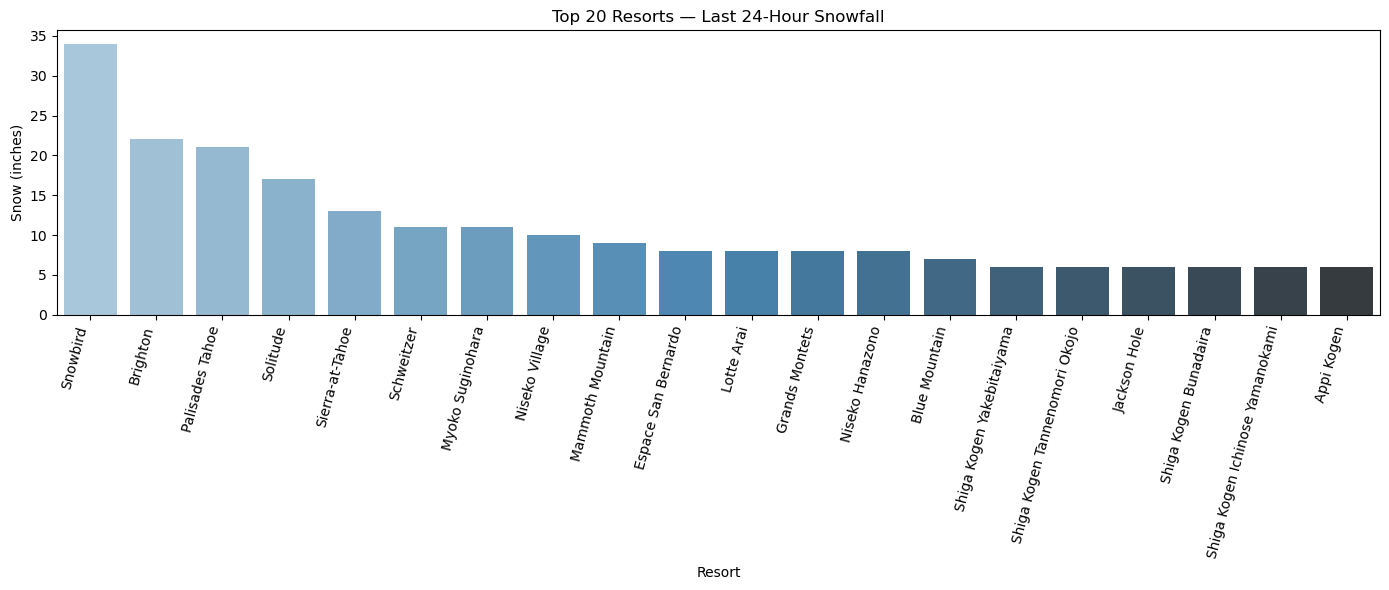

In [50]:
# -------------------------------
# Cell: Past 24-Hour Snowfall Analysis
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Work on a copy
df_24 = df_new.copy()

# Ensure numeric snowfall
df_24["last_24hr_snow"] = pd.to_numeric(
    df_24["last_24hr_snow"], errors="coerce"
)

# Drop missing or zero snowfall (optional: comment out zero filter if desired)
df_24 = df_24.dropna(subset=["last_24hr_snow"])
df_24 = df_24[df_24["last_24hr_snow"] > 0]

print("Summary of last 24hr snowfall:")
display(df_24["last_24hr_snow"].describe())

# Show top resorts table
top_n = 20
df_top = df_24.sort_values(
    "last_24hr_snow", ascending=False
).head(top_n)

display(
    df_top[
        ["resort_name", "location", "last_24hr_snow"]
    ]
)

# Plot
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_top,
    x="resort_name",
    y="last_24hr_snow",
    palette="Blues_d"
)

plt.xticks(rotation=75, ha="right")
plt.title("Top 20 Resorts — Last 24-Hour Snowfall")
plt.ylabel("Snow (inches)")
plt.xlabel("Resort")
plt.tight_layout()
plt.show()


In [51]:
# Show first 10 locations with full info
df_new[["resort_name", "latitude","longitude"]].head(10)


,resort_name,latitude,longitude
0,3 Zinnen (3 Peaks) Dolomites,46.7127,12.3641
1,Alpe di Siusi,46.5312,11.6258
2,Alpental at Snoqualmie,47.4361,-121.4354
3,Alyeska,60.9604,-149.0908
4,Appi Kogen,39.9882,140.9620
5,Arabba,46.4842,11.8729
6,Arapahoe Basin,39.6324,-105.8710
7,Banff Sunshine,51.0924,-115.7667
8,Bear Mountain,34.2186,-116.8604
9,Big Sky,45.2811,-111.4302


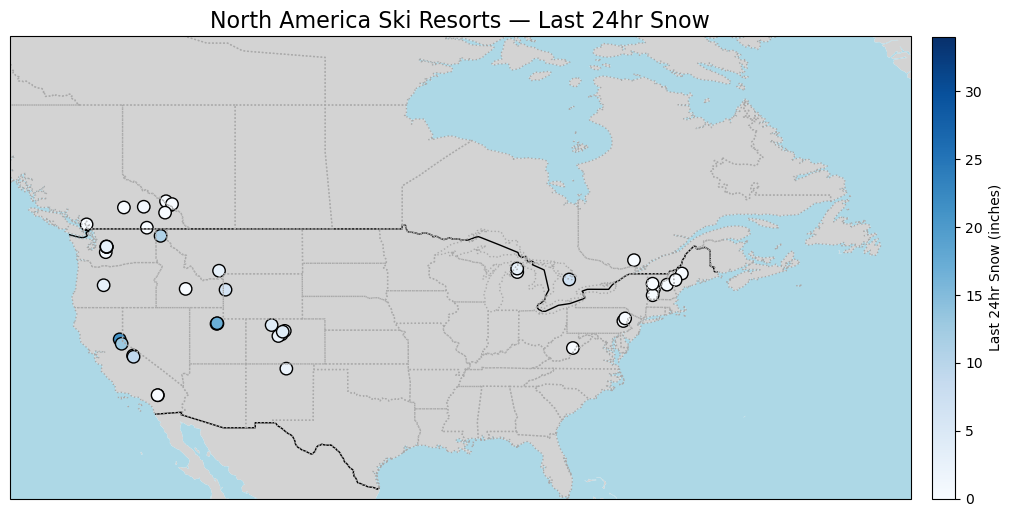

In [52]:
# -------------------------------
# Cell: North America Resorts — Map Overlay with Cartopy
# -------------------------------

import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Ensure numeric snow column
df_new["last_24hr_snow"] = pd.to_numeric(df_new["last_24hr_snow"], errors="coerce")

# Drop rows with missing snow or coordinates
df_map = df_new.dropna(subset=["last_24hr_snow", "latitude", "longitude"])

# Define rough North America bounding box
lon_min, lon_max = -130, -50
lat_min, lat_max = 25, 60

# Filter for North America
df_na = df_map[
    (df_map["longitude"] >= lon_min) &
    (df_map["longitude"] <= lon_max) &
    (df_map["latitude"] >= lat_min) &
    (df_map["latitude"] <= lat_max)
]

# Create a map with PlateCarree projection
fig = plt.figure(figsize=(14,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='darkgray', linestyle=':')

# Plot resorts as scatter points
sc = ax.scatter(
    df_na["longitude"],
    df_na["latitude"],
    c=df_na["last_24hr_snow"],
    cmap="Blues",
    s=80,
    edgecolor="k",
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.6, pad=0.02)
cbar.set_label("Last 24hr Snow (inches)")

# Title
plt.title("North America Ski Resorts — Last 24hr Snow", fontsize=16)
plt.show()


### Northeast US snow last 24 hours

/var/folders/yq/blfjj9vn7vvf5tt08v98q_qr0000gn/T/ipykernel_89182/2359193925.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("turbo", 256)  # 256 levels


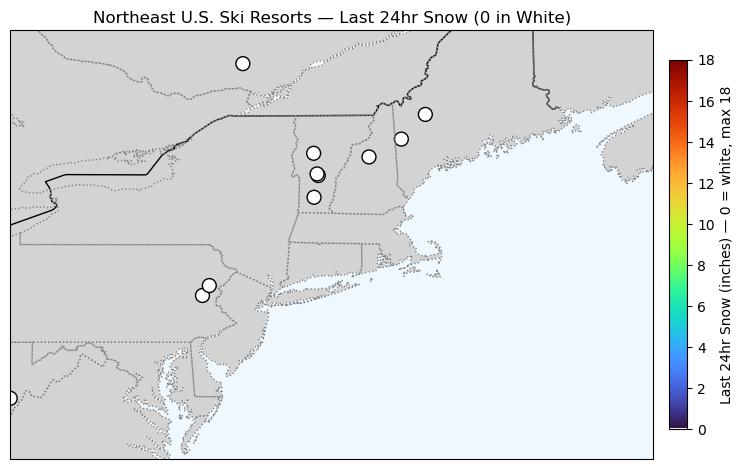

In [53]:
# -------------------------------
# Northeast Resorts — 0 inches white + NOAA-style colors
# -------------------------------

import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Ensure numeric snow column
df_new["last_24hr_snow"] = pd.to_numeric(df_new["last_24hr_snow"], errors="coerce")

# Drop rows with missing snow or coordinates
df_map = df_new.dropna(subset=["last_24hr_snow", "latitude", "longitude"])

# Northeast U.S. bounding box
lon_min, lon_max = -80, -65
lat_min, lat_max = 37, 47

df_ne = df_map[
    (df_map["longitude"] >= lon_min) &
    (df_map["longitude"] <= lon_max) &
    (df_map["latitude"] >= lat_min) &
    (df_map["latitude"] <= lat_max)
]

# Scale circle size
snow = df_ne["last_24hr_snow"].fillna(0)
sizes = np.interp(snow, (snow.min(), snow.max()), (30, 100))

# Create a custom colormap: 0 = white, >0 = turbo
base_cmap = plt.cm.get_cmap("turbo", 256)  # 256 levels
colors = base_cmap(np.arange(256))
colors[0] = np.array([1, 1, 1, 1])  # set lowest color to white
custom_cmap = LinearSegmentedColormap.from_list("turbo_white0", colors)

# Normalize from 0 to 18 inches
norm = Normalize(vmin=0, vmax=18)

# Create map
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray', linestyle=':')

# Scatter plot
sc = ax.scatter(
    df_ne["longitude"],
    df_ne["latitude"],
    c=df_ne["last_24hr_snow"],
    s=sizes,
    cmap=custom_cmap,
    norm=norm,
    edgecolor="k",
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.6, pad=0.02)
cbar.set_label("Last 24hr Snow (inches) — 0 = white, max 18")

plt.title("Northeast U.S. Ski Resorts — Last 24hr Snow (0 in White)")
plt.show()


### Northeast snow forecast 1-15 days

/var/folders/yq/blfjj9vn7vvf5tt08v98q_qr0000gn/T/ipykernel_89182/2922107112.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("turbo", 256)


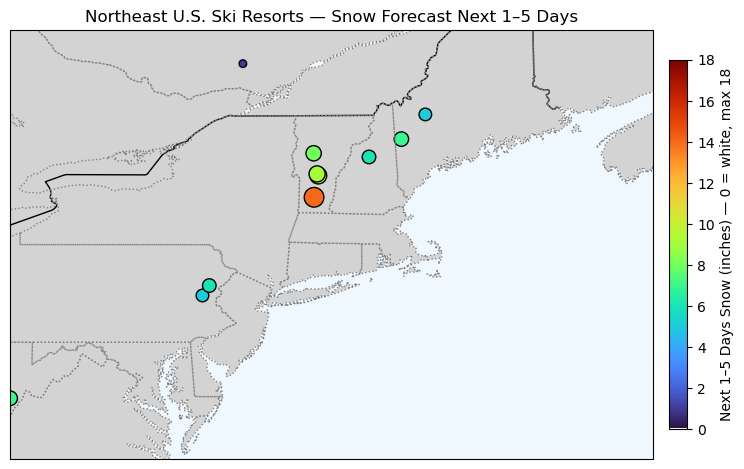

In [54]:
# -------------------------------
# Northeast Resorts — Snow Forecast (Next 1–5 Days)
# -------------------------------

# Ensure numeric forecast column
df_new["next_1_5_days"] = pd.to_numeric(df_new["next_1_5_days"], errors="coerce")

# Drop rows with missing forecast or coordinates
df_map = df_new.dropna(subset=["next_1_5_days", "latitude", "longitude"])

# Northeast U.S. bounding box
lon_min, lon_max = -80, -65
lat_min, lat_max = 37, 47

df_ne = df_map[
    (df_map["longitude"] >= lon_min) &
    (df_map["longitude"] <= lon_max) &
    (df_map["latitude"] >= lat_min) &
    (df_map["latitude"] <= lat_max)
]

# Scale circle size
snow = df_ne["next_1_5_days"].fillna(0)
sizes = np.interp(snow, (snow.min(), snow.max()), (30, 200))

# Create custom colormap: 0 = white, >0 = turbo
base_cmap = plt.cm.get_cmap("turbo", 256)
colors = base_cmap(np.arange(256))
colors[0] = np.array([1, 1, 1, 1])  # set 0 to white
custom_cmap = LinearSegmentedColormap.from_list("turbo_white0", colors)

# Normalize 0–18 inches
norm = Normalize(vmin=0, vmax=18)

# Create map
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray', linestyle=':')

# Scatter plot
sc = ax.scatter(
    df_ne["longitude"],
    df_ne["latitude"],
    c=df_ne["next_1_5_days"],
    s=sizes,
    cmap=custom_cmap,
    norm=norm,
    edgecolor="k",
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.6, pad=0.02)
cbar.set_label("Next 1–5 Days Snow (inches) — 0 = white, max 18")

plt.title("Northeast U.S. Ski Resorts — Snow Forecast Next 1–5 Days")
plt.show()


### Cycling forecast map for the entire us

In [55]:
import folium
from folium import FeatureGroup
import numpy as np

# Northeast bounding box (adjustable)
lon_min, lon_max = -130, -50
lat_min, lat_max = 25, 60

# Filter NE resorts
df_ne = df_new[
    (df_new["longitude"] >= lon_min) &
    (df_new["longitude"] <= lon_max) &
    (df_new["latitude"] >= lat_min) &
    (df_new["latitude"] <= lat_max)
].dropna(subset=["next_1_5_days","next_6_10_days","next_11_15_days"])

# NOAA‑style color mapping function
def noaa_color(snow):
    if snow is None or snow == 0:
        return "#ffffff"  # white for zero
    # Define color buckets
    if snow <= 3:
        return "#a6cee3"  # light cyan
    elif snow <= 6:
        return "#1f78b4"  # medium blue
    elif snow <= 9:
        return "#33a02c"  # green
    elif snow <= 12:
        return "#ffdd57"  # yellow
    elif snow <= 15:
        return "#fd8d3c"  # orange
    else:
        return "#e31a1c"  # red

# Initialize map
m = folium.Map(
    location=[42, -73],
    zoom_start=6,
    tiles="OpenStreetMap"
)
# Forecast periods & labels
periods = ["last_24hr_snow","next_1_5_days","next_6_10_days","next_11_15_days"]
labels = ["Last 24 Hours","Next 1–5 Days","Next 6–10 Days","Next 11–15 Days"]

for col, label in zip(periods, labels):
    fg = FeatureGroup(name=label)
    for _, row in df_ne.iterrows():
        snow = row[col]
        # Scale circle size (min 5 — max 15)
        radius = np.interp(snow if snow else 0, [0,18],[5,15])
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=radius,
            color="black",
            fill=True,
            fill_color=noaa_color(snow),
            fill_opacity=0.8,
            popup=f"{row['resort_name']}<br>{label}: {snow} in"
        ).add_to(fg)
    fg.add_to(m)

# Layer control
folium.LayerControl().add_to(m)

# Custom NOAA‑style legend
legend_html = """
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 180px; height: 230px;
background-color: white; z-index: 9999;
font-size:14px; padding: 10px; border:2px solid grey;">
<b>Snow (inches)</b><br>
<i style='background:#ffffff;width:20px;height:20px;display:inline-block'></i>&nbsp;0<br>
<i style='background:#a6cee3;width:20px;height:20px;display:inline-block'></i>&nbsp;1–3<br>
<i style='background:#1f78b4;width:20px;height:20px;display:inline-block'></i>&nbsp;4–6<br>
<i style='background:#33a02c;width:20px;height:20px;display:inline-block'></i>&nbsp;7–9<br>
<i style='background:#ffdd57;width:20px;height:20px;display:inline-block'></i>&nbsp;10–12<br>
<i style='background:#fd8d3c;width:20px;height:20px;display:inline-block'></i>&nbsp;13–15<br>
<i style='background:#e31a1c;width:20px;height:20px;display:inline-block'></i>&nbsp;16–18+
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m
